<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/11_world_happiness_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load each year separately
df_2015 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/World Happiness/2015.csv')
df_2016 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/World Happiness/2016.csv')
df_2017 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/World Happiness/2017.csv')
df_2018 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/World Happiness/2018.csv')
df_2019 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/World Happiness/2019.csv')

# Check column names for each year
for year, d in zip([2015,2016,2017,2018,2019], [df_2015,df_2016,df_2017,df_2018,df_2019]):
    print(year, list(d.columns))
    print()


Mounted at /content/drive
2015 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2016 ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2017 ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

2018 ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

2019 ['Overall rank', 'Country or region', 'Score', 'GDP

In [3]:
# Standardize column names - mapping each year's columns to a common schema
column_map = {
    'Country': 'country', 'Country or region': 'country',
    'Region': 'region',
    'Happiness Rank': 'rank', 'Happiness.Rank': 'rank', 'Overall rank': 'rank',
    'Happiness Score': 'happiness_score', 'Happiness.Score': 'happiness_score', 'Score': 'happiness_score',
    'Economy (GDP per Capita)': 'gdp_per_capita', 'Economy..GDP.per.Capita.': 'gdp_per_capita', 'GDP per capita': 'gdp_per_capita',
    'Health (Life Expectancy)': 'life_expectancy', 'Health..Life.Expectancy.': 'life_expectancy', 'Healthy life expectancy': 'life_expectancy',
    'Freedom': 'freedom', 'Freedom to make life choices': 'freedom',
    'Trust (Government Corruption)': 'trust', 'Trust..Government.Corruption.': 'trust', 'Perceptions of corruption': 'trust',
    'Generosity': 'generosity',
    'Family': 'social_support', 'Social support': 'social_support'
}

def standardize(df, year):
    df = df.rename(columns=column_map)
    df['year'] = year
    keep_cols = ['country', 'region', 'happiness_score', 'gdp_per_capita',
                 'life_expectancy', 'freedom', 'trust', 'generosity', 'social_support', 'year']
    existing_cols = [c for c in keep_cols if c in df.columns]
    return df[existing_cols]

df_2015 = standardize(df_2015, 2015)
df_2016 = standardize(df_2016, 2016)
df_2017 = standardize(df_2017, 2017)
df_2018 = standardize(df_2018, 2018)
df_2019 = standardize(df_2019, 2019)

df_2015.head()

,country,region,happiness_score,gdp_per_capita,life_expectancy,freedom,trust,generosity,social_support,year
0,Switzerland,Western Europe,7.587,1.39651,0.94143,0.66557,0.41978,0.29678,1.34951,2015
1,Iceland,Western Europe,7.561,1.30232,0.94784,0.62877,0.14145,0.43630,1.40223,2015
2,Denmark,Western Europe,7.527,1.32548,0.87464,0.64938,0.48357,0.34139,1.36058,2015
3,Norway,Western Europe,7.522,1.45900,0.88521,0.66973,0.36503,0.34699,1.33095,2015
4,Canada,North America,7.427,1.32629,0.90563,0.63297,0.32957,0.45811,1.32261,2015


In [4]:
# Combine all years into one dataframe
df = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019], ignore_index=True)
print(df.shape)
df.head()

(782, 10)


,country,region,happiness_score,gdp_per_capita,life_expectancy,freedom,trust,generosity,social_support,year
0,Switzerland,Western Europe,7.587,1.39651,0.94143,0.66557,0.41978,0.29678,1.34951,2015
1,Iceland,Western Europe,7.561,1.30232,0.94784,0.62877,0.14145,0.43630,1.40223,2015
2,Denmark,Western Europe,7.527,1.32548,0.87464,0.64938,0.48357,0.34139,1.36058,2015
3,Norway,Western Europe,7.522,1.45900,0.88521,0.66973,0.36503,0.34699,1.33095,2015
4,Canada,North America,7.427,1.32629,0.90563,0.63297,0.32957,0.45811,1.32261,2015


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          782 non-null    object 
 1   region           315 non-null    object 
 2   happiness_score  782 non-null    float64
 3   gdp_per_capita   782 non-null    float64
 4   life_expectancy  782 non-null    float64
 5   freedom          782 non-null    float64
 6   trust            781 non-null    float64
 7   generosity       782 non-null    float64
 8   social_support   782 non-null    float64
 9   year             782 non-null    int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 61.2+ KB


**2. Data Cleaning**

In [7]:
# Check missing values per year
df.isnull().groupby(df['year']).sum()

,country,region,happiness_score,gdp_per_capita,life_expectancy,freedom,trust,generosity,social_support,year
year,,,,,,,,,,
2015,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0
2017,0,155,0,0,0,0,0,0,0,0
2018,0,156,0,0,0,0,1,0,0,0
2019,0,156,0,0,0,0,0,0,0,0


In [8]:
# 'region' isn't present in later years - fill using 2015/2016 mapping where available
region_map = df_2015.set_index('country')['region'].to_dict()
df['region'] = df['country'].map(region_map)
df['region'] = df['region'].fillna('Unknown')

df['region'].value_counts()

,count
region,
Sub-Saharan Africa,182
Central and Eastern Europe,144
Latin America and Caribbean,105
Western Europe,103
Middle East and Northern Africa,96
Southeastern Asia,44
Southern Asia,35
Eastern Asia,28
Unknown,25


In [9]:
# Standardize inconsistent country names across years
name_fixes = {
    'United States of America': 'United States',
    'Congo (Kinshasa)': 'DR Congo',
    'Congo (Brazzaville)': 'Congo',
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'Hong Kong S.A.R., China': 'Hong Kong',
    'Taiwan Province of China': 'Taiwan',
    'North Macedonia': 'Macedonia'
}
df['country'] = df['country'].replace(name_fixes)

In [10]:
# Check for duplicate country-year combinations
df.duplicated(subset=['country', 'year']).sum()

np.int64(0)

In [11]:
# Drop rows with missing core score
df = df.dropna(subset=['happiness_score'])
df.shape

(782, 10)

**3. Univariate Analysis**

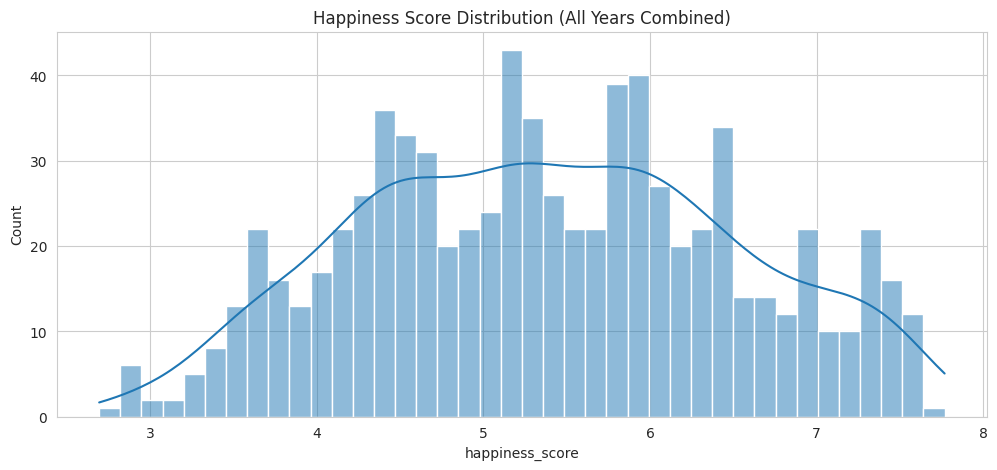

In [12]:
# Happiness score distribution overall
plt.figure(figsize=(12,5))
sns.histplot(df['happiness_score'], bins=40, kde=True)
plt.title('Happiness Score Distribution (All Years Combined)')
plt.show()

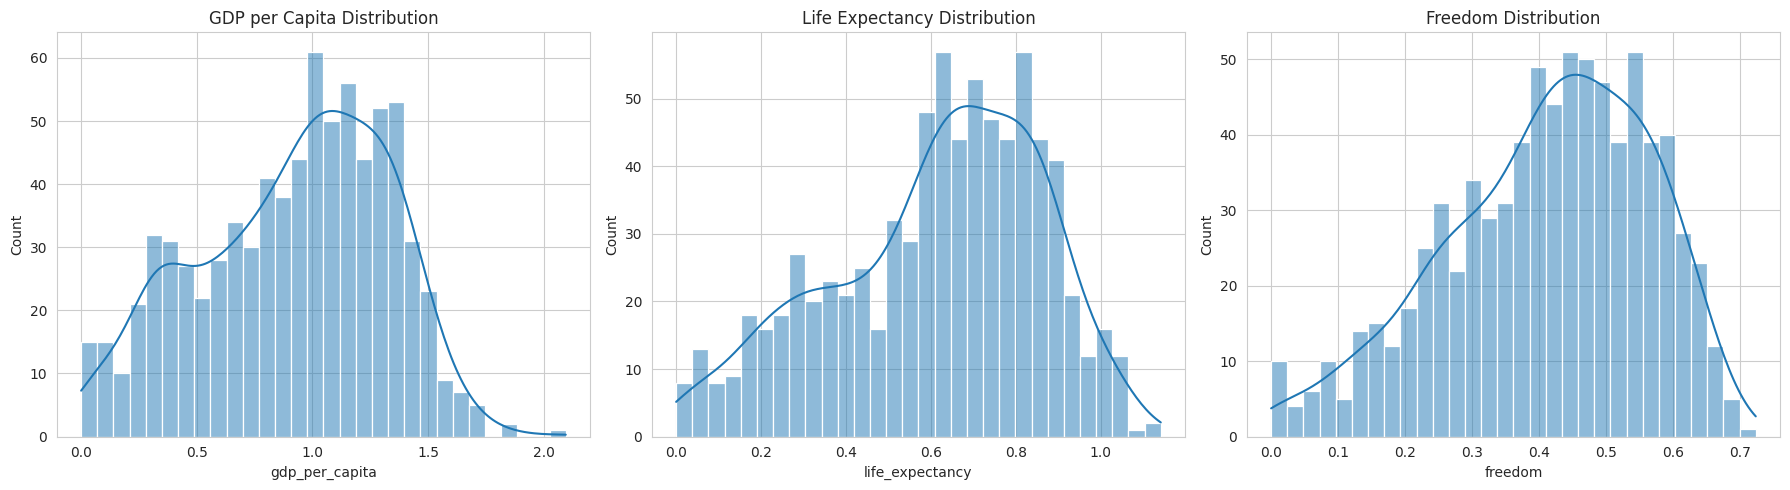

In [13]:
# GDP, life expectancy, freedom distributions
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['gdp_per_capita'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('GDP per Capita Distribution')

sns.histplot(df['life_expectancy'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Life Expectancy Distribution')

sns.histplot(df['freedom'].dropna(), bins=30, kde=True, ax=axes[2])
axes[2].set_title('Freedom Distribution')

plt.tight_layout()
plt.show()

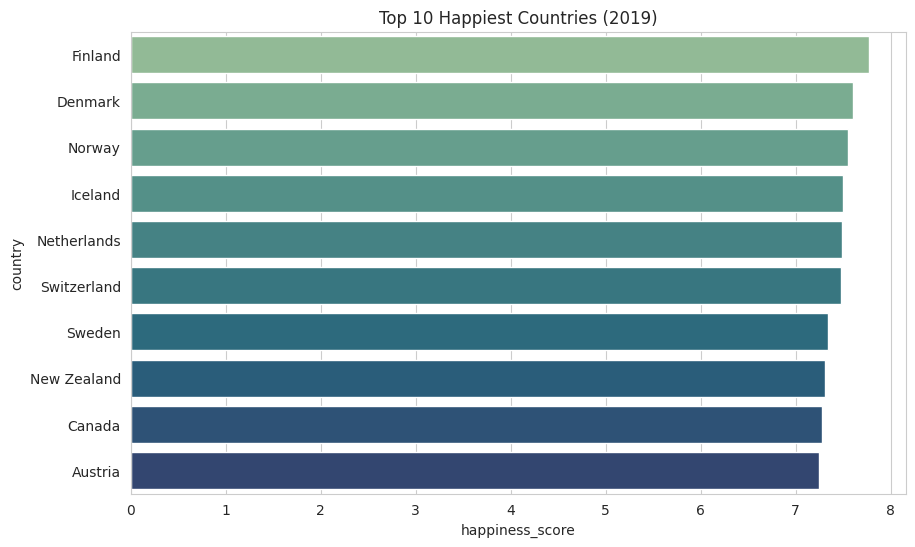

In [14]:
# Top 10 happiest countries - latest year
latest_year = df['year'].max()
top10 = df[df['year'] == latest_year].nlargest(10, 'happiness_score')[['country', 'happiness_score']]

sns.barplot(data=top10, x='happiness_score', y='country', hue='country', palette='crest', legend=False)
plt.title(f'Top 10 Happiest Countries ({latest_year})')
plt.show()

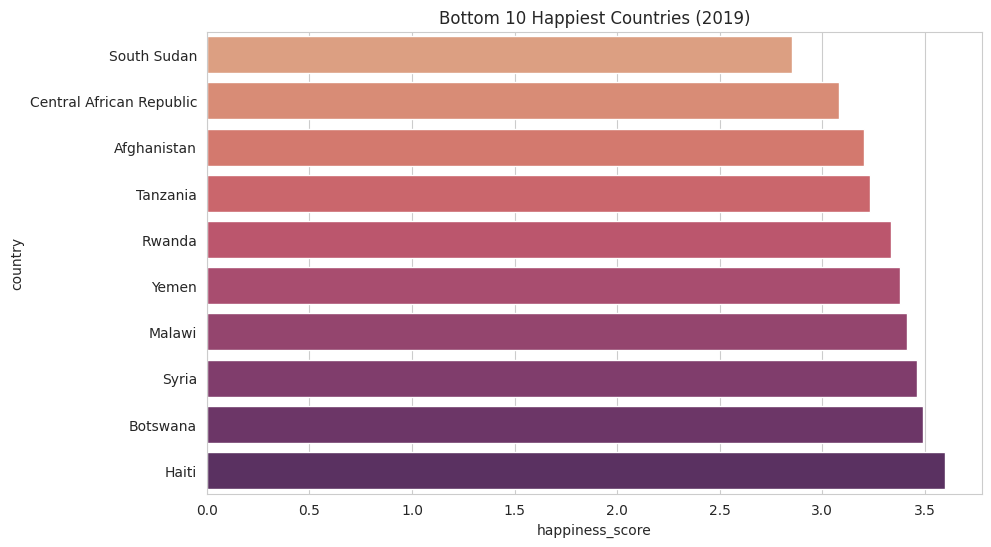

In [15]:
# Bottom 10 happiest countries - latest year
bottom10 = df[df['year'] == latest_year].nsmallest(10, 'happiness_score')[['country', 'happiness_score']]

sns.barplot(data=bottom10, x='happiness_score', y='country', hue='country', palette='flare', legend=False)
plt.title(f'Bottom 10 Happiest Countries ({latest_year})')
plt.show()

**4. Trend / Comparison Analysis**

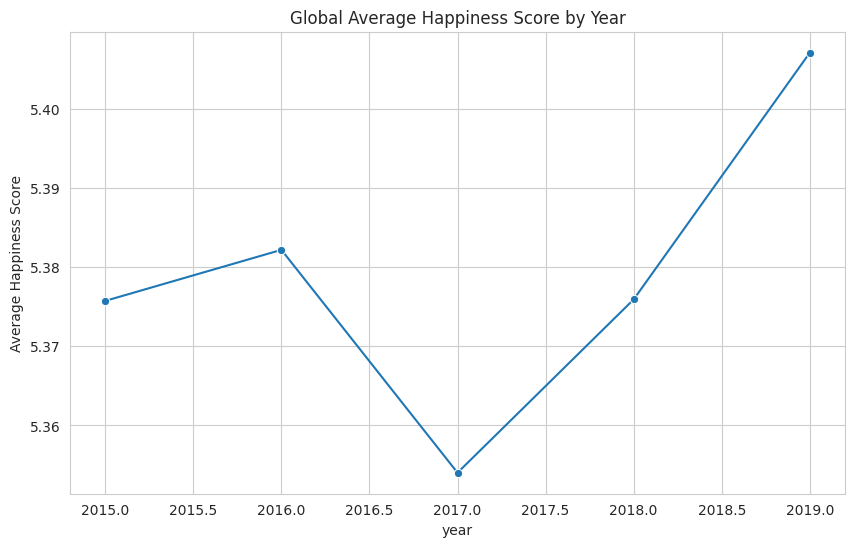

In [16]:
# Global average happiness score by year
yearly_avg = df.groupby('year')['happiness_score'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o')
plt.title('Global Average Happiness Score by Year')
plt.ylabel('Average Happiness Score')
plt.show()

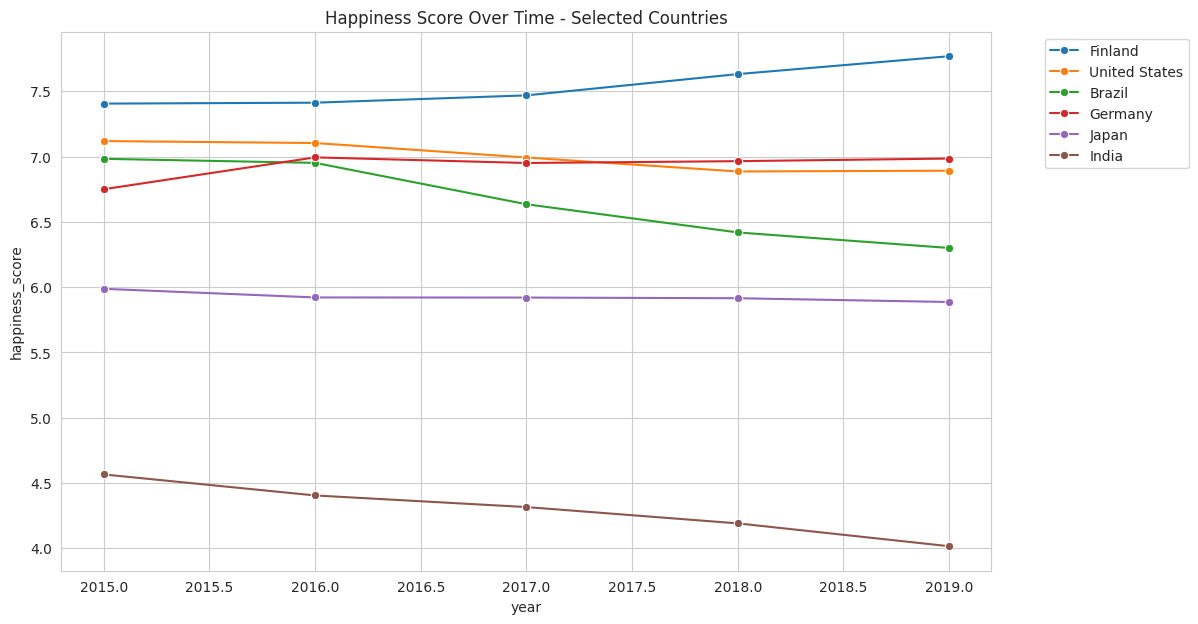

In [17]:
# Track specific countries over the years
countries_to_track = ['United States', 'India', 'Finland', 'Germany', 'Brazil', 'Japan']
subset = df[df['country'].isin(countries_to_track)]

plt.figure(figsize=(12,7))
sns.lineplot(data=subset, x='year', y='happiness_score', hue='country', marker='o')
plt.title('Happiness Score Over Time - Selected Countries')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

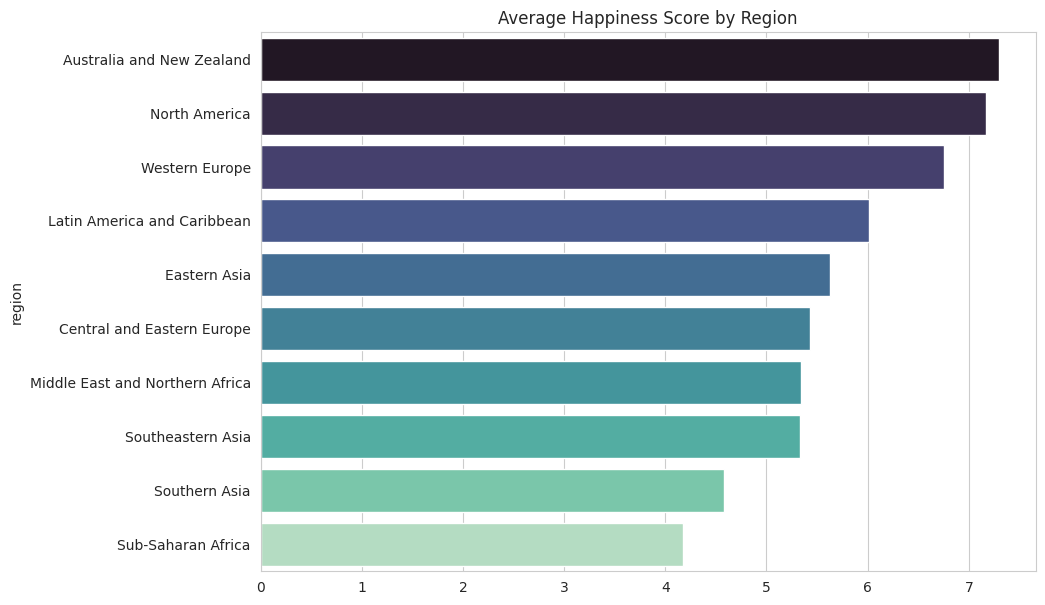

In [18]:
# Region-level comparison (using the mapped region from 2015/2016)
region_avg = df[df['region'] != 'Unknown'].groupby('region')['happiness_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=region_avg.values, y=region_avg.index, hue=region_avg.index, palette='mako', legend=False)
plt.title('Average Happiness Score by Region')
plt.show()

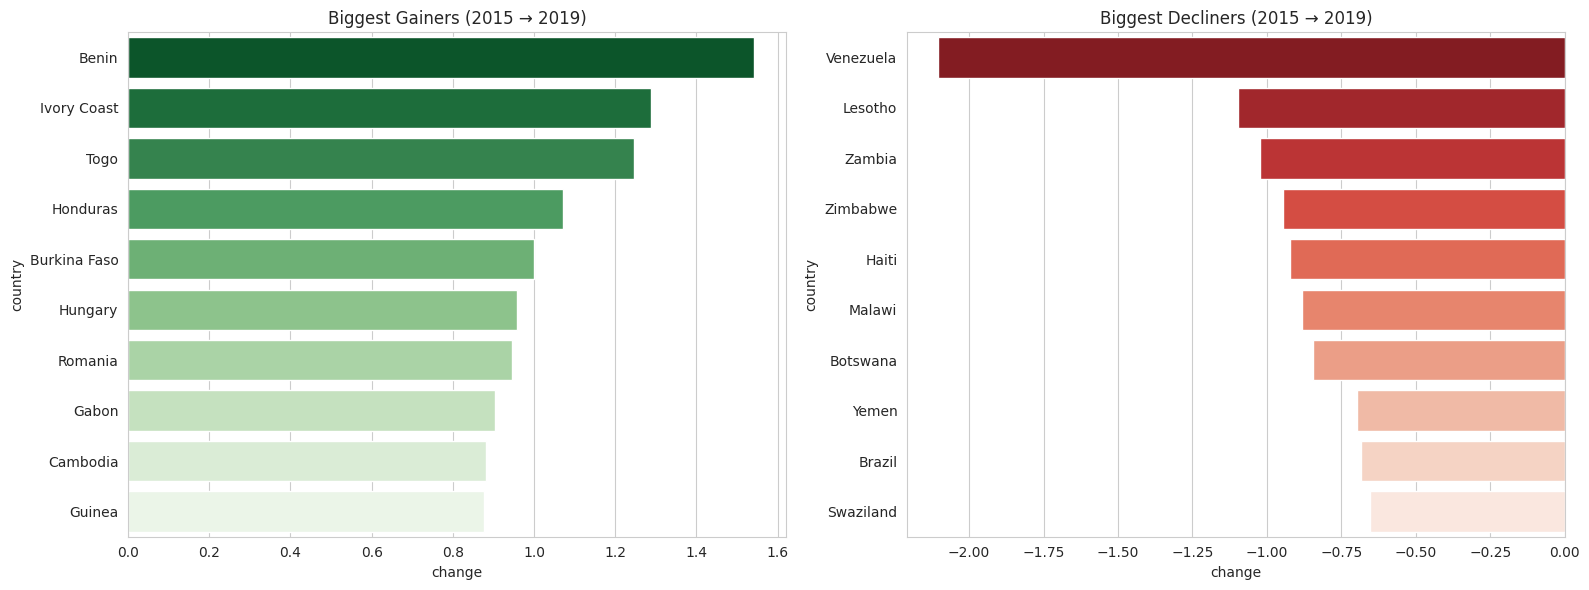

In [19]:
# Biggest gainers/decliners between first and last year
first_year = df['year'].min()
pivot = df[df['year'].isin([first_year, latest_year])].pivot_table(
    index='country', columns='year', values='happiness_score')
pivot = pivot.dropna()
pivot['change'] = pivot[latest_year] - pivot[first_year]

gainers = pivot.sort_values('change', ascending=False).head(10)
decliners = pivot.sort_values('change').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(x=gainers['change'], y=gainers.index, hue=gainers.index, palette='Greens_r', legend=False, ax=axes[0])
axes[0].set_title(f'Biggest Gainers ({first_year} → {latest_year})')

sns.barplot(x=decliners['change'], y=decliners.index, hue=decliners.index, palette='Reds_r', legend=False, ax=axes[1])
axes[1].set_title(f'Biggest Decliners ({first_year} → {latest_year})')

plt.tight_layout()
plt.show()

**5. Multivariate Analysis**

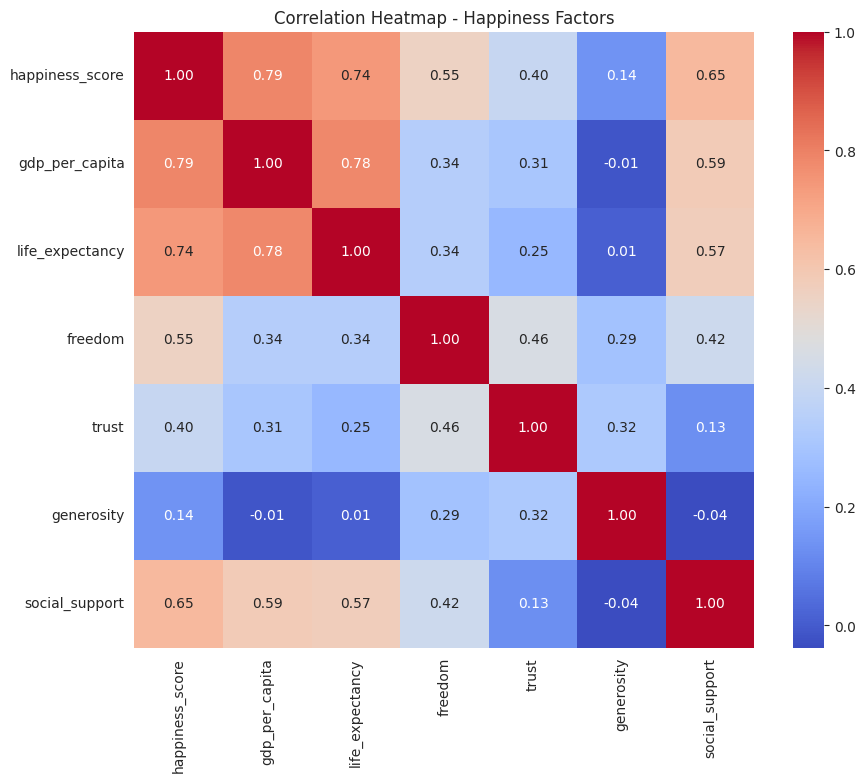

In [20]:
# Correlation heatmap
numeric_cols = ['happiness_score', 'gdp_per_capita', 'life_expectancy', 'freedom', 'trust', 'generosity', 'social_support']
numeric_cols = [c for c in numeric_cols if c in df.columns]

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Happiness Factors')
plt.show()

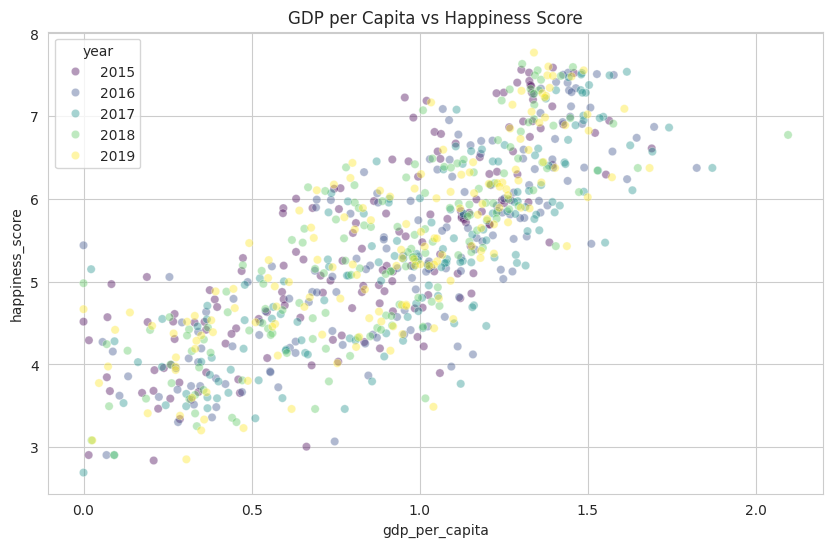

In [21]:
# GDP per capita vs happiness score
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gdp_per_capita', y='happiness_score', alpha=0.4, hue='year', palette='viridis')
plt.title('GDP per Capita vs Happiness Score')
plt.show()

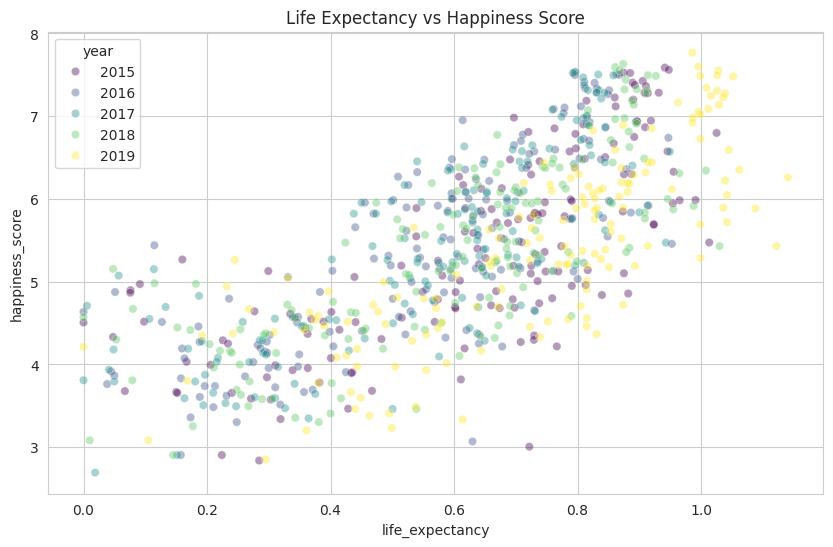

In [22]:
# Life expectancy vs happiness score
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='life_expectancy', y='happiness_score', alpha=0.4, hue='year', palette='viridis')
plt.title('Life Expectancy vs Happiness Score')
plt.show()

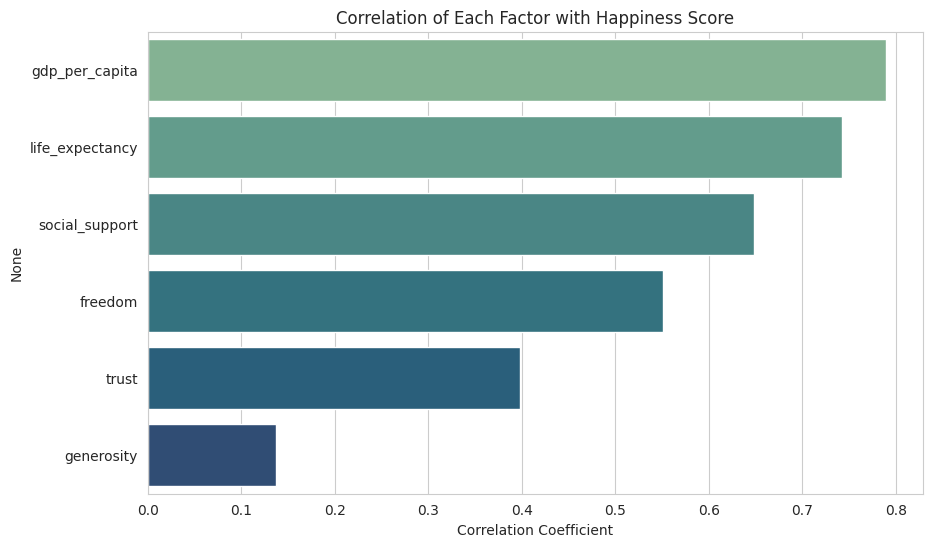

In [23]:
# Which factor correlates most strongly with happiness?
factor_corr = df[numeric_cols].corr()['happiness_score'].drop('happiness_score').sort_values(ascending=False)

sns.barplot(x=factor_corr.values, y=factor_corr.index, hue=factor_corr.index, palette='crest', legend=False)
plt.title('Correlation of Each Factor with Happiness Score')
plt.xlabel('Correlation Coefficient')
plt.show()

**6. Insights Summary**

## Key Insights

- [Region] consistently ranks as the happiest region across the years studied, while [Region] ranks lowest.
- Global average happiness score has [risen/fallen/stayed flat] between [first_year] and [latest_year].
- GDP per capita shows a [strong/moderate] positive relationship with happiness, but the relationship flattens at higher income levels — supporting the "diminishing returns of wealth" idea.
- [Factor, e.g., social_support or life_expectancy] correlates most strongly with happiness score, arguably more than GDP itself.
- [Country] showed the largest happiness gain over the period, while [Country] saw the steepest decline — worth investigating context (economic/political events) outside this dataset.
- Trust in government/institutions tends to be [weakly/moderately] correlated with happiness compared to other factors.
- [Add 1-2 more insights specific to what you observed]